# 데이터프레임 결측치 처리(1)

1) 다음 요구사항에 맞게 순서대로 구문을 작성하고 확인하세요.

- 1-1) pandas 라이브러리를 pd 별칭을 주어 불러오세요.
- 1-2) 다음 파일을 읽어와 titanic 데이터프레임을 선언하세요.
    - 파일 : 'titanic_train.csv'
- 1-3) PassengerId, Name,Ticket, Cabin 열을 한 번에 제거하세요.

In [1]:
# 1-1) 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1-2) 데이터 읽어오기
path = 'data/titanic_train.csv'
titanic = pd.read_csv(path)

# 1-3) PassengerId, Name, Ticket, Cabin 열 삭제
titanic.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

2) 상위 5개 행을 확인하세요.

In [2]:
titanic.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [3]:
titanic.isna().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

3) 다음 요구사항에 맞게 순서대로 구문을 작성하고 확인하세요.

- 3-1) Age 열 결측치를 Age 열 평균으로 채우세요.
- 3-2) Embarked 열 결측치를 'S'로 채우세요.
- 3-3) 각 열에 결측치가 남아있는지 확인하세요.

In [7]:
# 3-1) Age 열 결측치를 Age 열 평균으로 채우세요.

Age_mean = titanic['Age'].mean()
titanic['Age'] = titanic['Age'].fillna(Age_mean)


In [8]:
# 3-2) Embarked 열 결측치를 'S'로 채우세요.
titanic['Embarked'] = titanic['Embarked'].fillna('S')   

In [9]:
# 3-3) 각 열에 결측치가 남아있는지 확인하세요.
titanic.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

4) 다음 요구사항에 맞게 순서대로 구문을 작성하고 확인하세요.

- 4-1) groupby 메소드를 사용해 Pclass 별 탑승자 수를 집계하여 tmp 데이터프레임으로 선언하세요.
    - Survived 열 count() 집계
- 4-2) tmp 데이터프레임 열 이름이 Pclass, Count가 되게 변경하세요.
- 4-3) tmp 데이터프레임을 막대 그래프로 시각화해 확인하세요.

In [10]:
# 4-1) groupby 메소드를 사용해 Pclass 별 생존자 수를 집계하여 tmp 데이터프레임으로 선언하세요.
tmp = titanic.groupby('Pclass', as_index=False)[['Survived']].count()
tmp.head()

,Pclass,Survived
0,1,216
1,2,184
2,3,491


In [11]:
# 4-2) tmp 데이터프레임 열 이름이 Pclass, Count가 되게 변경하세요.
# 방법 1
# tmp.columns = ['Pclass', 'Count']

# 방법 2
tmp.rename(columns={'Survived':'Count'}, inplace=True)

tmp.head()


,Pclass,Count
0,1,216
1,2,184
2,3,491


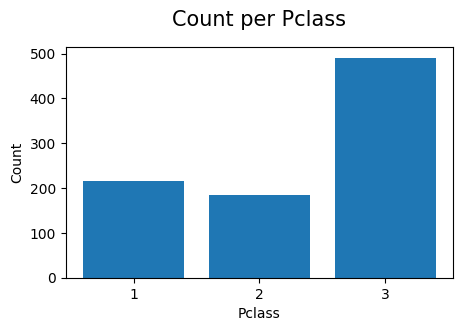

In [12]:
# 4-3) tmp 데이터프레임을 막대 그래프로 시각화해 확인하세요.
tmp['Pclass'] = tmp['Pclass'].astype(str)

plt.figure(figsize = (5,3))
plt.bar(tmp['Pclass'], tmp['Count'])
plt.title('Count per Pclass', size=15, pad=15)
plt.xlabel('Pclass')
plt.ylabel('Count')
plt.show()

5) Pclass, Sex, Embarked 열을 한 번에 가변수화하세요. 단, 다중공선성 문제가 없도록 범주값 개수보다 하나 적은 수의 열이 만들어지게 하세요.

In [13]:
# 가변수화
cols = ['Pclass', 'Sex', 'Embarked']

titanic = pd.get_dummies(titanic, columns=cols, drop_first=True)

titanic.head()

,Survived,Age,SibSp,Parch,Fare,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S
0,0,22.0,1,0,7.2500,False,True,True,False,True
1,1,38.0,1,0,71.2833,False,False,False,False,False
2,1,26.0,0,0,7.9250,False,True,False,False,True
3,1,35.0,1,0,53.1000,False,False,False,False,True
4,0,35.0,0,0,8.0500,False,True,True,False,True
